In [ ]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [52]:
sns.set_theme(style="whitegrid")

In [51]:
project_root = Path.cwd()
email_directory = project_root / "data" / "sample_emails"

In [53]:
# group submissions

FILE_PATTERN = re.compile(r"^(E\d{3})_(email|attachment_\d+)\.md$")

submissions: dict[str, dict] = {}

for file_path in email_directory.glob("*.md"):
    match = FILE_PATTERN.match(file_path.name)

    if match is None:
        print(f"Found an unexpected file name: {file_path.name}. skipping this file.")
        continue

    submission_id, document_type = match.groups()

    if submission_id not in submissions:
        submissions[submission_id] = {
            "email_path": None,
            "attachments": [],
        }

    if document_type == "email":
        submissions[submission_id]["email_path"] = file_path
    else:
        submissions[submission_id]["attachments"].append(file_path)

# validate submittions
for k, v in submissions.items():
    if v["email_path"] is None:
        print(f"{k=} does not have an email")

In [ ]:
# a helper function to get submission content by submission id
# needed to avoid storing all content into a memory


def read_submission(submission: str) -> dict:
    s = submissions[submission]

    return {
        "email_text": s["email_path"].read_text(),
        "attachment_text": [ap.read_text() for ap in s["attachments"]],
    }

In [45]:
# provide a general data report
print(f"Submissions loaded: {len(submissions)}")

total_attachments = sum([len(s["attachments"]) for s in submissions.values()])
print(f"Attachments loaded: {total_attachments}")
print(f"Total documents: {len(submissions) + total_attachments}")

Submissions loaded: 50
Attachments loaded: 126
Total documents: 176


In [ ]:
# compute metrics from the data
MONEY_PATTERN = re.compile(r"[£$€]\s?\d[\d,]*(?:\.\d+)?")

_metrics: list[dict] = []
for k in submissions:
    content = read_submission(k)
    attachment_count = len(content["attachment_text"])
    email_word_count = len(content["email_text"].split())
    attachment_word_count = sum([len(a.split()) for a in content["attachment_text"]])
    total_word_count = email_word_count + attachment_word_count
    email_currency_count = len(MONEY_PATTERN.findall(content["email_text"]))
    attachment_currency_count = sum(
        len(MONEY_PATTERN.findall(text)) for text in content["attachment_text"]
    )
    attachment_word_share = attachment_word_count / total_word_count

    _metrics.append(
        {
            "submission_id": k,
            "attachment_count": attachment_count,
            "email_word_count": email_word_count,
            "attachment_word_count": attachment_word_count,
            "total_word_count": total_word_count,
            "email_currency_count": email_currency_count,
            "attachment_currency_count": attachment_currency_count,
            "total_currency_count": email_currency_count + attachment_currency_count,
            "attachment_word_share": attachment_word_share,
        }
    )
metrics = pd.DataFrame(_metrics)

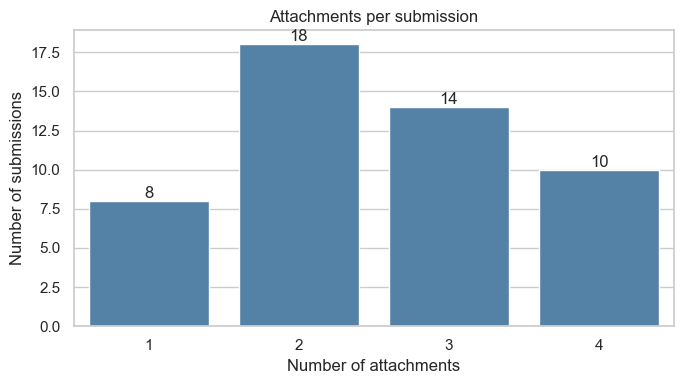

In [46]:
# Figure 1: attachment distribution

plt.figure(figsize=(7, 4))

ax = sns.countplot(
    data=metrics,
    x="attachment_count",
    color="steelblue",
)

# Add the number of submissions above each bar
for container in ax.containers:
    ax.bar_label(container)

plt.title("Attachments per submission")
plt.xlabel("Number of attachments")
plt.ylabel("Number of submissions")
plt.tight_layout()

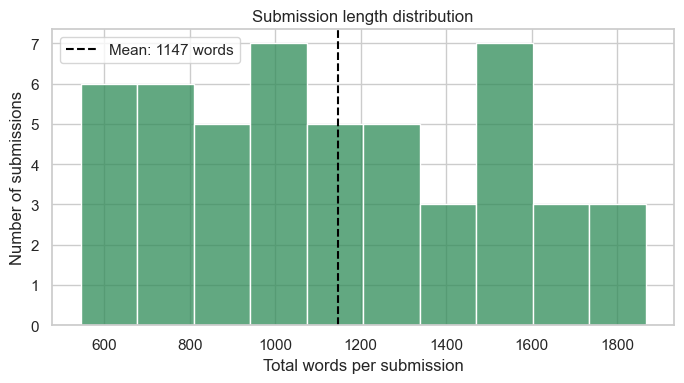

In [47]:
# Figure 2: submission length
plt.figure(figsize=(7, 4))

sns.histplot(
    data=metrics,
    x="total_word_count",
    bins=10,
    color="seagreen",
    edgecolor="white",
)

mean_word_count = metrics["total_word_count"].mean()

# Show the mean as a vertical dashed line
plt.axvline(
    mean_word_count,
    color="black",
    linestyle="--",
    label=f"Mean: {mean_word_count:.0f} words",
)

plt.title("Submission length distribution")
plt.xlabel("Total words per submission")
plt.ylabel("Number of submissions")
plt.legend()
plt.tight_layout()

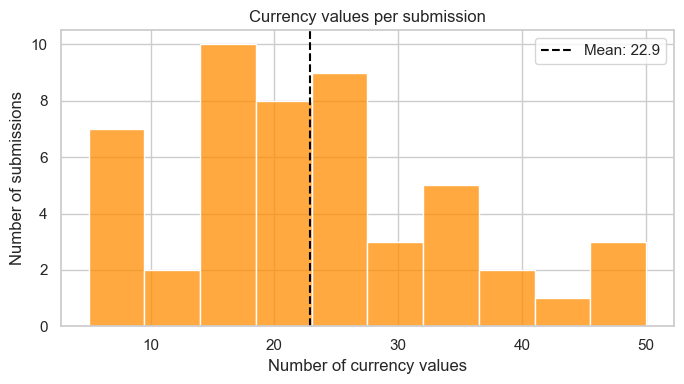

In [48]:
# Figure 3: number of currency values
plt.figure(figsize=(7, 4))

sns.histplot(
    data=metrics,
    x="total_currency_count",
    bins=10,
    color="darkorange",
    edgecolor="white",
)

mean_currency_count = metrics["total_currency_count"].mean()

# Show the mean as a vertical dashed line
plt.axvline(
    mean_currency_count,
    color="black",
    linestyle="--",
    label=f"Mean: {mean_currency_count:.1f}",
)

plt.title("Currency values per submission")
plt.xlabel("Number of currency values")
plt.ylabel("Number of submissions")
plt.legend()
plt.tight_layout()

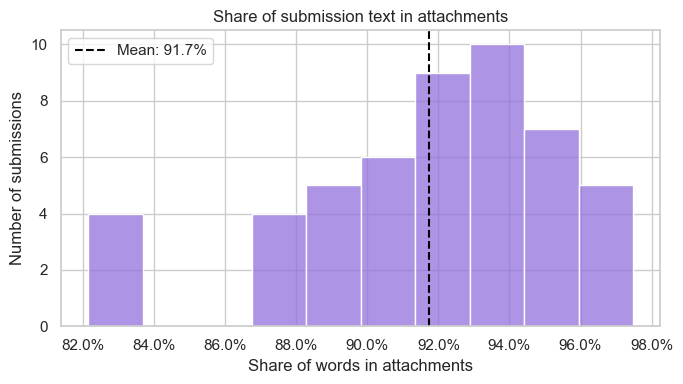

In [49]:
plt.figure(figsize=(7, 4))

sns.histplot(
    data=metrics,
    x="attachment_word_share",
    bins=10,
    color="mediumpurple",
    edgecolor="white",
)

mean_share = metrics["attachment_word_share"].mean()

plt.axvline(
    mean_share,
    color="black",
    linestyle="--",
    label=f"Mean: {mean_share:.1%}",
)

plt.title("Share of submission text in attachments")
plt.xlabel("Share of words in attachments")
plt.ylabel("Number of submissions")
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
plt.legend()
plt.tight_layout()